In [4]:
from pathlib import Path
import xarray as xr
import numpy as np
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import functools
from concurrent.futures import ThreadPoolExecutor

In [ ]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[2]

FOLDER_cloud = f'{repo_root}\\..\\sentinel_data\\S5P_Cloud'
nc_files_cloud = [f for f in os.listdir(FOLDER_cloud) if f.endswith('.nc')]

FOLDER_aero = f'{repo_root}\\..\\sentinel_data\\S5P_Aerosol_Index'
nc_files_aero = [f for f in os.listdir(FOLDER_aero) if f.endswith('.nc')]

FOLDER_nitro = f'{repo_root}\\..\\sentinel_data\\S5P_Nitrogen'
nc_files_nitro = [f for f in os.listdir(FOLDER_nitro) if f.endswith('.nc')]

FOLDER_ozone = f'{repo_root}\\..\\sentinel_data\\S5P_Ozone'
nc_files_ozone = [f for f in os.listdir(FOLDER_ozone) if f.endswith('.nc')]

FOLDER_forma = f'{repo_root}\\..\\sentinel_data\\S5P_Formaldehyde'
nc_files_forma = [f for f in os.listdir(FOLDER_forma) if f.endswith('.nc')]

FOLDER_carbon = f'{repo_root}\\..\\sentinel_data\\S5P_Carbon'
nc_files_carbon = [f for f in os.listdir(FOLDER_carbon) if f.endswith('.nc')]

FOLDER_methane = f'{repo_root}\\..\\sentinel_data\\S5P_Methane'
nc_files_methane = [f for f in os.listdir(FOLDER_methane) if f.endswith('.nc')]

FOLDER_sulfur = f'{repo_root}\\..\\sentinel_data\\S5P_Sulfur'
nc_files_sulfur = [f for f in os.listdir(FOLDER_sulfur) if f.endswith('.nc')]

In [5]:
def _process_file(args):
    file, var, FOLDER = args
    location = os.path.join(FOLDER, file)
    ds = xr.open_dataset(location)

    ds = ds.sortby('time')

    valid_mask = ds[var].count(dim=['lat', 'lon']) > 0
    ds = ds.sel(time=valid_mask)

    counts_per_time = ds[var].count(dim=['lat', 'lon'])
    total_pixels = ds.lon.size * ds.lat.size
    coverage_ratio = counts_per_time / total_pixels

    monthly_avg = coverage_ratio.resample(time='MS').mean()

    df = monthly_avg.to_dataframe(name=var).reset_index()
    df['time'] = df['time'].dt.strftime('%Y-%m')
    ds.close()
    return df

def fractions_monthly_df_robust(files, var: str, FOLDER, n_workers=5):
    args = [(file, var, FOLDER) for file in files]
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        dfs = list(executor.map(_process_file, args))

    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.groupby('time', as_index=False)[var].mean()
    combined = combined.sort_values('time').reset_index(drop=True)
    return combined

In [6]:
def _process_file(args):
    file, var, FOLDER = args
    location = os.path.join(FOLDER, file)
    ds = xr.open_dataset(location)

    counts_per_time = ds[var].count(dim=['lat', 'lon'])
    total_pixels = ds.lon.size * ds.lat.size
    coverage_ratio = counts_per_time / total_pixels

    monthly_avg = coverage_ratio.resample(time='MS').mean()

    df = monthly_avg.to_dataframe(name=var).reset_index()
    df['time'] = df['time'].dt.strftime('%Y-%m')
    ds.close()
    return df

def fractions_monthly_df(files, var: str, FOLDER, n_workers=4):
    args = [(file, var, FOLDER) for file in files]
    with ThreadPoolExecutor(max_workers=n_workers) as executor:
        dfs = list(executor.map(_process_file, args))
    return pd.concat(dfs, ignore_index=True)

### Aerosol

In [7]:
if __name__ == '__main__' and not os.path.exists("aerosol_fractions.csv"):
    df_merged = fractions_monthly_df_robust(nc_files_aero, 'absorbing_aerosol_index', FOLDER_aero); print('Done', flush = True)
    df_merged.to_csv("aerosol_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Cloud

In [8]:
if __name__ == '__main__' and not os.path.exists("cloud_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_cloud, 'cloud_fraction', FOLDER_cloud)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_cloud, 'cloud_top_pressure', FOLDER_cloud)); print('Done 2', flush = True)
    df.append(fractions_monthly_df(nc_files_cloud, 'cloud_top_height', FOLDER_cloud)); print('Done 3', flush = True)
    df.append(fractions_monthly_df(nc_files_cloud, 'cloud_base_pressure', FOLDER_cloud)); print('Done 4', flush = True)
    df.append(fractions_monthly_df(nc_files_cloud, 'cloud_base_height', FOLDER_cloud)); print('Done 5', flush = True)
    df.append(fractions_monthly_df(nc_files_cloud, 'cloud_optical_depth', FOLDER_cloud)); print('Done 6', flush = True)

    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("cloud_fractions.csv", index=False)
else:
    print("Data exists from before!")


Data exists from before!


---

### Nitrogen

In [9]:
if __name__ == '__main__' and not os.path.exists("nitrogen_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_nitro, 'NO2_column_number_density', FOLDER_nitro)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_nitro, 'tropospheric_NO2_column_number_density', FOLDER_nitro)); print('Done 2', flush = True)
    df.append(fractions_monthly_df(nc_files_nitro, 'stratospheric_NO2_column_number_density', FOLDER_nitro)); print('Done 3', flush = True)
    df.append(fractions_monthly_df(nc_files_nitro, 'NO2_slant_column_number_density', FOLDER_nitro)); print('Done 4', flush = True)

    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("nitrogen_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Ozone

In [10]:
if __name__ == '__main__' and not os.path.exists("ozone_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_ozone, 'O3_column_number_density', FOLDER_ozone)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_ozone, 'O3_effective_temperature', FOLDER_ozone)); print('Done 2', flush = True)
    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("ozone_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Formaldehyde

In [11]:
if __name__ == '__main__' and not os.path.exists("formaldehyde_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_forma, 'tropospheric_HCHO_column_number_density', FOLDER_forma)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_forma, 'tropospheric_HCHO_column_number_density_amf', FOLDER_forma)); print('Done 2', flush = True)
    df.append(fractions_monthly_df(nc_files_forma, 'HCHO_slant_column_number_density', FOLDER_forma)); print('Done 3', flush = True)
    df.append(fractions_monthly_df(nc_files_forma, 'cloud_fraction', FOLDER_forma)); print('Done 4', flush = True)
    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("formaldehyde_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Carbon

In [12]:
if __name__ == '__main__' and not os.path.exists("carbon_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_carbon, 'CO_column_number_density', FOLDER_carbon)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_carbon, 'H2O_column_number_density', FOLDER_carbon)); print('Done 2', flush = True)
    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("carbon_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Methane

In [13]:
if __name__ == '__main__' and not os.path.exists("methane_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_methane, 'CH4_column_volume_mixing_ratio_dry_air', FOLDER_methane)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_methane, 'aerosol_height', FOLDER_methane)); print('Done 2', flush = True)
    df.append(fractions_monthly_df(nc_files_methane, 'aerosol_optical_depth', FOLDER_methane)); print('Done 3', flush = True)
    df.append(fractions_monthly_df(nc_files_methane, 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected', FOLDER_methane)); print('Done 4', flush = True)
    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("methane_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Sulfur

In [14]:
if __name__ == '__main__' and not os.path.exists("sulfur_fractions.csv"):
    df = []
    df.append(fractions_monthly_df(nc_files_sulfur, 'SO2_column_number_density', FOLDER_sulfur)); print('Done 1', flush = True)
    df.append(fractions_monthly_df(nc_files_sulfur, 'SO2_column_number_density_amf', FOLDER_sulfur)); print('Done 2', flush = True)
    df.append(fractions_monthly_df(nc_files_sulfur, 'SO2_slant_column_number_density', FOLDER_sulfur)); print('Done 3', flush = True)
    df.append(fractions_monthly_df(nc_files_sulfur, 'SO2_column_number_density_15km', FOLDER_sulfur)); print('Done 4', flush = True)
    df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), df)
    df_merged.to_csv("sulfur_fractions.csv", index=False)
else:
    print("Data exists from before!")

Data exists from before!


---

### Heatmap

In [15]:
data_names = [f for f in os.listdir() if f.endswith('fractions.csv')]
dfs = []
for f in data_names:
    dfs.append(pd.read_csv(f))

df_merged = functools.reduce(lambda left, right: pd.merge(left, right, on='time', how='inner'), dfs)

In [16]:
df_merged.columns

Index(['time', 'absorbing_aerosol_index', 'CO_column_number_density',
       'H2O_column_number_density', 'cloud_fraction_x', 'cloud_top_pressure',
       'cloud_top_height', 'cloud_base_pressure', 'cloud_base_height',
       'cloud_optical_depth', 'tropospheric_HCHO_column_number_density',
       'tropospheric_HCHO_column_number_density_amf',
       'HCHO_slant_column_number_density', 'cloud_fraction_y',
       'CH4_column_volume_mixing_ratio_dry_air', 'aerosol_height',
       'aerosol_optical_depth',
       'CH4_column_volume_mixing_ratio_dry_air_bias_corrected',
       'NO2_column_number_density', 'tropospheric_NO2_column_number_density',
       'stratospheric_NO2_column_number_density',
       'NO2_slant_column_number_density', 'O3_column_number_density',
       'O3_effective_temperature', 'SO2_column_number_density',
       'SO2_column_number_density_amf', 'SO2_slant_column_number_density',
       'SO2_column_number_density_15km'],
      dtype='object')

In [25]:
df_merged[['HCHO_slant_column_number_density', 'cloud_fraction_y', 'tropospheric_HCHO_column_number_density', 'tropospheric_HCHO_column_number_density_amf']].describe().iloc[1].mean()

np.float64(0.39931893925723916)

In [27]:
df_merged[['SO2_column_number_density', 'SO2_column_number_density_amf', 'SO2_slant_column_number_density', 'SO2_column_number_density_15km']].describe().iloc[1].mean()

np.float64(0.5227444645729097)

In [28]:
df_merged[['CH4_column_volume_mixing_ratio_dry_air', 'aerosol_height', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 'aerosol_optical_depth']].describe().iloc[1].mean()

np.float64(0.12418587642126751)

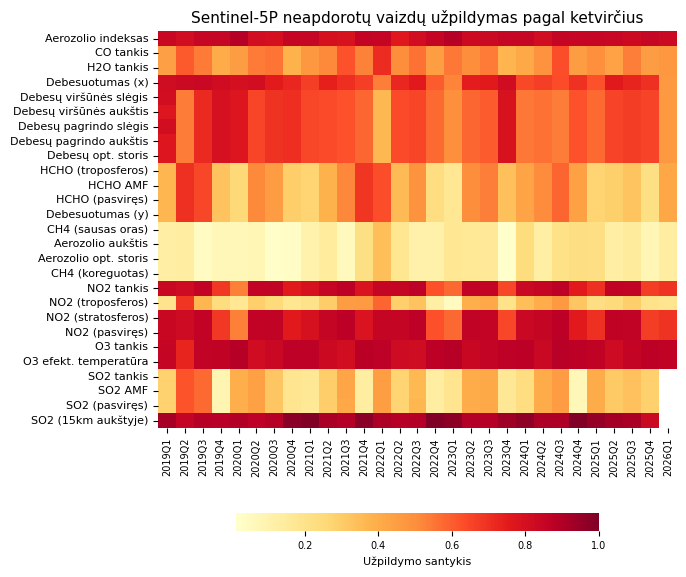

In [18]:
df_merged['time'] = pd.to_datetime(df_merged['time'])
df_quarterly = df_merged.set_index('time')

df_resampled = df_quarterly.resample('QS').mean()

df_resampled.index = df_resampled.index.to_period('Q').astype(str)

translations = {
    'absorbing_aerosol_index': 'Aerozolio indeksas',
    'CO_column_number_density': 'CO tankis',
    'H2O_column_number_density': 'H2O tankis',
    'cloud_fraction_x': 'Debesuotumas (x)',
    'cloud_top_pressure': 'Debesų viršūnės slėgis',
    'cloud_top_height': 'Debesų viršūnės aukštis',
    'cloud_base_pressure': 'Debesų pagrindo slėgis',
    'cloud_base_height': 'Debesų pagrindo aukštis',
    'cloud_optical_depth': 'Debesų opt. storis',
    'tropospheric_HCHO_column_number_density': 'HCHO (troposferos)',
    'tropospheric_HCHO_column_number_density_amf': 'HCHO AMF',
    'HCHO_slant_column_number_density': 'HCHO (pasviręs)',
    'cloud_fraction_y': 'Debesuotumas (y)',
    'CH4_column_volume_mixing_ratio_dry_air': 'CH4 (sausas oras)',
    'aerosol_height': 'Aerozolio aukštis',
    'aerosol_optical_depth': 'Aerozolio opt. storis',
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': 'CH4 (koreguotas)',
    'NO2_column_number_density': 'NO2 tankis',
    'tropospheric_NO2_column_number_density': 'NO2 (troposferos)',
    'stratospheric_NO2_column_number_density': 'NO2 (stratosferos)',
    'NO2_slant_column_number_density': 'NO2 (pasviręs)',
    'O3_column_number_density': 'O3 tankis',
    'O3_effective_temperature': 'O3 efekt. temperatūra',
    'SO2_column_number_density': 'SO2 tankis',
    'SO2_column_number_density_amf': 'SO2 AMF',
    'SO2_slant_column_number_density': 'SO2 (pasviręs)',
    'SO2_column_number_density_15km': 'SO2 (15km aukštyje)'
}

df_to_plot = df_resampled.T
df_to_plot.index = df_to_plot.index.map(lambda x: translations.get(x, x))

width_inch = 17 / 2.54
height_inch = width_inch * 1.1

plt.figure(figsize=(width_inch, height_inch))
ax = sns.heatmap(
    df_to_plot,
    cmap="YlOrRd",
    cbar_kws={
        'orientation': 'horizontal', 
        'label': 'Užpildymo santykis',
        'shrink': 0.7
    }
)

# plt.suptitle("Sentinel-5P neapdorotų vaizdų užpildymas pagal ketvirčius", fontsize=12)
plt.title("Sentinel-5P neapdorotų vaizdų užpildymas pagal ketvirčius", fontsize=11)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=8)

cbar = ax.collections[0].colorbar
cbar.set_label('Užpildymo santykis', fontsize=8) 
cbar.ax.tick_params(labelsize=7)

# plt.tight_layout()
plt.savefig("sentinel_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [39]:
group_mapping = {
    'absorbing_aerosol_index': 'Aerozoliai',
    'aerosol_height': 'Aerozoliai',
    'aerosol_optical_depth': 'Aerozoliai',
    
    'cloud_fraction_x': 'Debesys',
    'cloud_top_pressure': 'Debesys',
    'cloud_top_height': 'Debesys',
    'cloud_base_pressure': 'Debesys',
    'cloud_base_height': 'Debesys',
    'cloud_optical_depth': 'Debesys',
    
    'tropospheric_NO2_column_number_density': 'Azoto dioksidas (NO2)',
    'stratospheric_NO2_column_number_density': 'Azoto dioksidas (NO2)',
    'NO2_column_number_density': 'Azoto dioksidas (NO2)',
    'NO2_slant_column_number_density': 'Azoto dioksidas (NO2)',
    
    'SO2_column_number_density': 'Sieros dioksidas (SO2)',
    'SO2_column_number_density_amf': 'Sieros dioksidas (SO2)',
    'SO2_slant_column_number_density': 'Sieros dioksidas (SO2)',
    'SO2_column_number_density_15km': 'Sieros dioksidas (SO2)',
    
    'tropospheric_HCHO_column_number_density': 'Formaldehidas (HCHO)',
    'tropospheric_HCHO_column_number_density_amf': 'Formaldehidas (HCHO)',
    'HCHO_slant_column_number_density': 'Formaldehidas (HCHO)',
    'cloud_fraction_y': 'Formaldehidas (HCHO)',
    
    'CH4_column_volume_mixing_ratio_dry_air': 'Metanas (CH4)',
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': 'Metanas (CH4)',
    
    'CO_column_number_density': 'Anglies monoksidas (CO)',
    'H2O_column_number_density': 'Anglies monoksidas (CO)',

    'O3_column_number_density': 'Ozonas (O3)',
    'O3_effective_temperature': 'Ozonas (O3)'
}

In [40]:
df_to_plot = df_resampled.T

df_grouped = df_to_plot.groupby(group_mapping).mean()

desired_order = ['Aerozoliai', 'Debesys', 'Azoto dioksidas (NO2)', 'Sieros dioksidas (SO2)', 
                 'Formaldehidas (HCHO)', 'Metanas (CH4)', 'Anglies monoksidas (CO)', 'Ozonas (O3)']
df_grouped = df_grouped.reindex(desired_order)

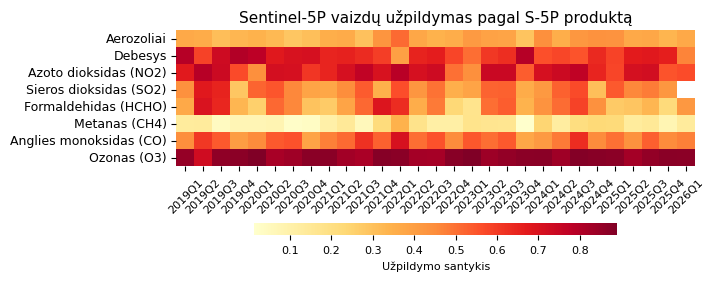

In [64]:
height_inch = width_inch * 0.44
plt.figure(figsize=(width_inch, height_inch))
ax = sns.heatmap(
    df_grouped,
    cmap="YlOrRd",
    # annot=True,
    fmt=".2f",
    cbar_kws={
        'orientation': 'horizontal', 
        'label': 'Vidutinis užpildymo santykis',
        'shrink': 0.7,
        'aspect': 30,
        'pad': 0.25
    }
)

plt.title("Sentinel-5P vaizdų užpildymas pagal S-5P produktą", fontsize=11)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=9)

cbar = ax.collections[0].colorbar
cbar.set_label('Užpildymo santykis', fontsize=8) 
cbar.ax.tick_params(labelsize=8)

plt.savefig("sentinel_heatmap_v2.png", dpi=300, bbox_inches='tight')
plt.show()